In [67]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Collecting the data and preprocessing it

In [68]:
#load the csv to pandas dataframe
GD = pd.read_csv('gld_price_data.csv')

In [69]:
#prints top 5 rows
GD.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [70]:
#prints bottom 5 rows
GD.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [71]:
#returns number of rows and columns present
GD.shape

(2290, 6)

In [72]:
#to get some basic info of data
GD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [73]:
#retuns number of null values in a column
GD.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [74]:
#gets the statistical measures of the data
GD.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Checking Correlation
            # always the diagonals have perfect correlation(relation with itself)
            # correlation always ranges from -1 to 1
            # 0.9 to 0.6 & -0.9 to -0.6 are generally considered good correlation

In [75]:
correlation = GD.corr(numeric_only = True)

Text(0.5, 1.0, 'Correlation')

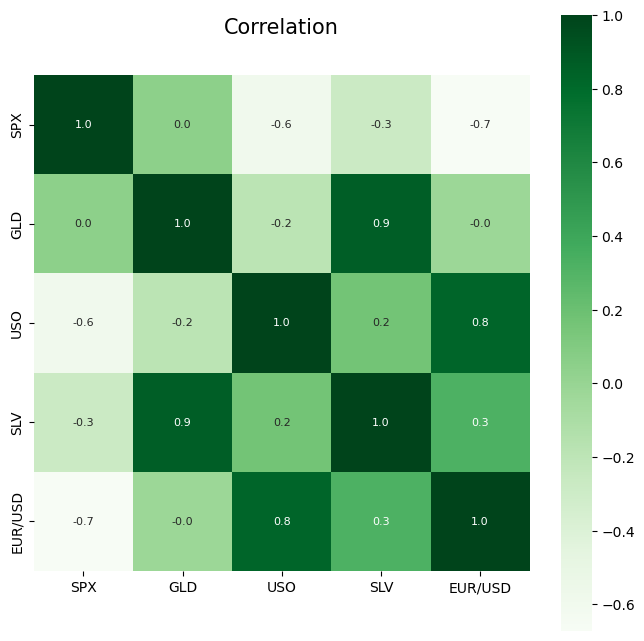

In [77]:
#constructing heatmap for correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size':8}, cmap = 'Greens') 
plt.title('Correlation', fontsize = 15, pad = 30)

In [78]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


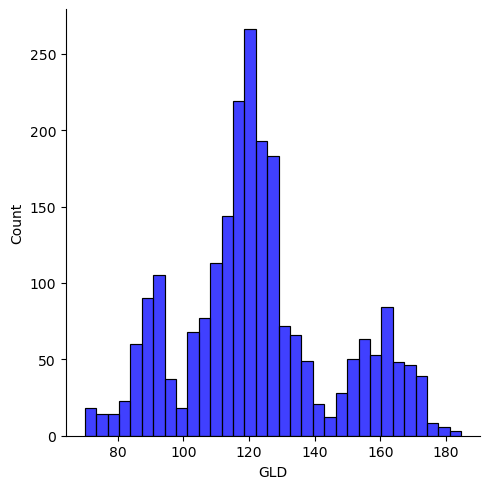

In [80]:
sns.displot(GD['GLD'], color = 'blue') # sns.histplot(GD['GLD'], color = 'green') can also be used

Splitting of Features and Target

In [81]:
X = GD.drop(['Date','GLD'], axis = 1)#we remove GLD from the new dataframe as it is the actual value 
# and having it in the X will mislead the outcome and standard regression algo can't read date as it's string format(reads only num) 
Y = GD['GLD'] #target
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [82]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training and Testing

In [83]:
X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

Model Training using Random Forest Regressor

In [84]:
regressor = RandomForestRegressor(n_estimators = 100)

In [85]:
#Training the model 
regressor.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model Evaluation

In [86]:
#Prediction on test data
test_data_prediction = regressor.predict(X_test)
print(test_data_prediction)

[168.33419923  82.3563999  115.85420001 127.74040107 120.69770108
 154.7673982  150.08889874 126.1751     117.3873988  126.18930012
 116.50500122 171.79640107 141.00109823 168.12679894 115.16760027
 117.56220018 138.58040346 169.75890128 158.72230246 158.17570039
 155.2266001  125.22920052 175.83849942 157.11540348 125.24160039
  93.68949929  77.53580011 120.71189997 119.11289951 167.50789965
  88.09510075 125.41009987  91.27370084 117.67210007 121.15729864
 135.92970021 115.3206012  115.31620063 147.4183996  107.33590109
 104.56830243  87.24189801 126.57220069 117.97180008 151.78339923
 119.51880027 108.36869979 108.00119789  93.33100061 127.04619817
  75.18940046 113.71029943 121.37470014 111.23779878 118.80439874
 120.55459962 159.14289959 167.894901   147.28289654  85.7467986
  94.27900027  86.88949872  90.53500035 118.73600078 126.38930067
 127.5297     168.79670033 122.21799904 117.19289868  98.80300055
 168.56000128 143.15359884 131.54720278 121.20660231 121.63219956
 119.608300

In [87]:
#R Squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R Squared error : ",error_score)

R Squared error :  0.988958298296912


Compare the Actual values and Predicted values in a plot

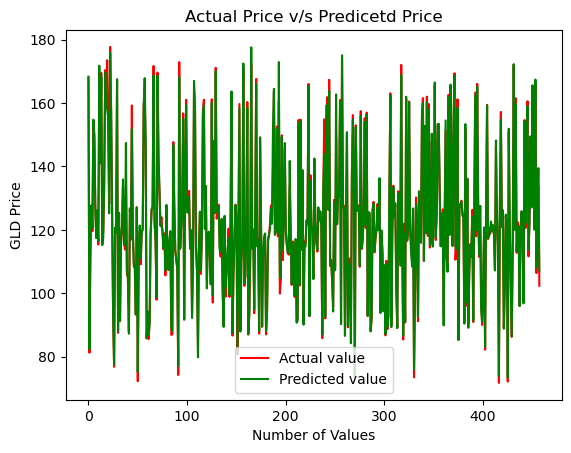

In [89]:
Y_test = list(Y_test) # converts pandas series to python list
plt.plot(Y_test, color = 'red', label = 'Actual value')
plt.plot(test_data_prediction, color = 'green', label = 'Predicted value')
plt.title('Actual Price v/s Predicetd Price')
plt.xlabel('Number of Values')
plt.ylabel('GLD Price')
plt.legend() # small explanatory box for indication of color used to depict what is what
plt.show()